In [1]:
# Import necessary libraries for data manipulation, visualization, and geographical operations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the population data for various wards in Delhi, including boundary information
pop = pd.read_csv('pop.csv')

In [3]:
# Remove the 'sc_population' column as it's not required for the current analysis
pop.drop(['sc_population'],axis = 1, inplace = True)

In [4]:
# Load the EV charger data from the specified Excel file
charger = pd.read_excel('ev_charger_loc.xlsx')

In [5]:
# Set pandas option to display all columns (useful for inspecting wide DataFrames)
pd.set_option('display.max_columns', None)
# Display the first two rows of the 'charger' DataFrame to get a quick overview
charger.head(2)

,uid,name,vendor_name,address,latitude,longitude,city,country,open,close,logo_url,staff,payment_modes,contact_numbers,station_type,postal_code,zone,0,available,capacity,cost_per_unit,power_type,total,type,vehicle_type
0,STATIC12,GensolCharge Pvt. Ltd.,GensolCharge Pvt. Ltd.,"NDSE Grid, BRPL South Extension",28.568238,77.219666,Delhi,India,00:00:00,23:59:59,NaN,Unstaffed,"Card, E-Wallet, UPI","[""7042406677""]",charging,110001,central-delhi,NaN,NaN,15 kW,NaN,DC,2.0,BEVC DC 001,['4W']
1,STATIC14,REIL,REIL,Scada office kalka ji,28.541995,77.260583,Delhi,India,00:00:00,23:59:59,NaN,Unstaffed,E-Wallet,"[""11399999228""]",charging,110001,central-delhi,NaN,NaN,3.3 kW,NaN,AC,3.0,BEVC AC 001,"['2W', '3W', '4W']"


In [6]:
# Drop columns from the 'charger' DataFrame that are not relevant for the current analysis
charger.drop(['uid','vendor_name','city','country','logo_url','staff','payment_modes','contact_numbers','station_type',0,'available','cost_per_unit','vehicle_type','open','close','type','capacity','zone','power_type','postal_code','address'],axis=1, inplace = True)

In [7]:
# Print a concise summary of the 'charger' DataFrame, including data types and non-null values
charger.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2705 entries, 0 to 2704
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       2705 non-null   object 
 1   latitude   2705 non-null   float64
 2   longitude  2705 non-null   float64
 3   total      2497 non-null   float64
dtypes: float64(3), object(1)
memory usage: 84.7+ KB


In [8]:
# Check for null (missing) values in each column of the 'pop' DataFrame
pop.isnull().sum()

,0
wardno,0
ward,0
total_population,0
latitude,0
longitude,0
boundary_wkt,0


In [9]:
# Check for null (missing) values in each column of the 'charger' DataFrame
charger.isnull().sum()

,0
name,0
latitude,0
longitude,0
total,208


In [10]:
# Fill null values in the 'total' column of the 'charger' DataFrame with 1.
# This assumes that if the total number of chargers is unknown, there is at least one charger.
charger['total'].fillna(1, inplace=True)

/tmp/ipykernel_6010/3574575375.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  charger['total'].fillna(1, inplace=True)


In [11]:
# Check for duplicate rows in the 'pop' DataFrame
pop.duplicated().sum()

np.int64(0)

In [12]:
# Check for duplicate rows in the 'charger' DataFrame to identify potential data entry issues or repeated entries.
charger.duplicated().sum()

np.int64(496)

In [13]:
# Display the first 10 duplicate rows from the 'charger' DataFrame to understand the nature of duplicates.
print(charger[charger.duplicated()].head(10))

    name   latitude  longitude  total
19  BSES  28.655300  77.297900    1.0
21  BSES  28.655300  77.297900    3.0
54  EESL  28.572793  77.208662    2.0
55  EESL  28.572793  77.208662    2.0
62  EESL  28.618177  77.212590    4.0
63  EESL  28.618177  77.212590    4.0
65  EESL  28.633880  77.221078    1.0
80  EESL  28.556678  77.232601    2.0
81  EESL  28.556678  77.232601    2.0
82  EESL  28.556678  77.232601    2.0


In [14]:
# Sort the 'charger' DataFrame by 'total' in descending order to prioritize higher capacity chargers.
charger = charger.sort_values('total', ascending=False)
# Remove duplicate charger entries based on 'latitude' and 'longitude', keeping the first occurrence (which is the one with higher 'total' capacity due to sorting).
charger = charger.drop_duplicates(subset=['latitude', 'longitude'], keep='first')
# Reset the index of the DataFrame after dropping duplicates, discarding the old index.
charger.reset_index(drop=True, inplace=True)
# Print the new shape of the DataFrame to show how many rows remain after deduplication.
print(charger.shape)

(2040, 4)


In [15]:
# Print a concise summary of the 'charger' DataFrame, including data types and non-null values, after cleaning.
charger.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       2040 non-null   object 
 1   latitude   2040 non-null   float64
 2   longitude  2040 non-null   float64
 3   total      2040 non-null   float64
dtypes: float64(3), object(1)
memory usage: 63.9+ KB


In [16]:
# Print a concise summary of the 'pop' DataFrame, including data types and non-null values, to ensure data integrity.
pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wardno            250 non-null    int64  
 1   ward              250 non-null    object 
 2   total_population  250 non-null    int64  
 3   latitude          250 non-null    float64
 4   longitude         250 non-null    float64
 5   boundary_wkt      250 non-null    object 
dtypes: float64(2), int64(2), object(2)
memory usage: 11.8+ KB


In [17]:
# Print the shape of the 'pop' DataFrame (rows, columns).
print(pop.shape)
# Check for null values in the 'boundary_wkt' column of the 'pop' DataFrame.
print(pop['boundary_wkt'].isnull().sum())

(250, 6)
0


In [18]:
# Import necessary libraries for handling WKT (Well-Known Text) and working with geospatial data.
from shapely import wkt
import geopandas as gpd

# Convert the 'boundary_wkt' column in the 'pop' DataFrame from WKT strings to shapely geometry objects.
pop['geometry'] = pop['boundary_wkt'].apply(wkt.loads)

# Convert the 'pop' DataFrame into a GeoDataFrame, specifying the geometry column and its Coordinate Reference System (CRS).
pop_gdf = gpd.GeoDataFrame(pop, geometry='geometry', crs=4326)

# Convert the 'charger' DataFrame into a GeoDataFrame, creating point geometries from latitude and longitude.
ev_gdf = gpd.GeoDataFrame(charger,
    geometry=gpd.points_from_xy(charger.longitude, charger.latitude),
    crs=4326)

# Perform a spatial join between the EV charger GeoDataFrame and the population GeoDataFrame.
# This assigns a ward number to each charger if it falls within a ward's boundary.
ev_with_ward = gpd.sjoin(ev_gdf, pop_gdf, how='left', predicate='within')

# Print the shape of the resulting GeoDataFrame.
print(ev_with_ward.shape)
# Count and print the number of chargers that could not be assigned to a ward (null 'wardno').
print(ev_with_ward['wardno'].isnull().sum())

(2040, 12)
242


### Reprojecting to a Projected CRS

To ensure accurate spatial calculations (like `buffer` and `distance`), it's crucial to reproject the GeoDataFrames from a geographic coordinate system (like `EPSG:4326`) to a projected coordinate system. For Delhi, `EPSG:32643` (WGS 84 / UTM zone 43N) is a suitable choice as it provides measurements in meters.


In [19]:
# Define the projected CRS for Delhi (e.g., UTM Zone 43N, EPSG:32643)
projected_crs = "EPSG:32643"

# Reproject both GeoDataFrames to the projected CRS
pop_gdf_proj = pop_gdf.to_crs(projected_crs)
ev_gdf_proj = ev_gdf.to_crs(projected_crs)

print(f"Original pop_gdf CRS: {pop_gdf.crs}")
print(f"Projected pop_gdf CRS: {pop_gdf_proj.crs}")
print(f"Original ev_gdf CRS: {ev_gdf.crs}")
print(f"Projected ev_gdf CRS: {ev_gdf_proj.crs}")


Original pop_gdf CRS: EPSG:4326
Projected pop_gdf CRS: EPSG:32643
Original ev_gdf CRS: EPSG:4326
Projected ev_gdf CRS: EPSG:32643


### Re-running Spatial Join and Nearest Ward Assignment with Projected Data

Now that the data is in a projected CRS, we can re-run the spatial join and nearest ward assignment steps. The `buffer` operation will now be in meters, and `distance` calculations will also be accurate.

In [20]:
# Apply a small buffer to the ward geometries (e.g., 1 meter) in the projected CRS.
# This helps in cases where charger points might be exactly on the boundary or slightly outside due to precision issues.
pop_gdf_proj['geometry'] = pop_gdf_proj.geometry.buffer(1) # Buffer of 1 meter

# Perform the spatial join again using the 'within' predicate after buffering the ward geometries.
ev_with_ward_proj = gpd.sjoin(ev_gdf_proj, pop_gdf_proj, how='left', predicate='within')
# Print the count of chargers that are still not matched to any ward.
print(f"Chargers unmatched after initial projected spatial join: {ev_with_ward_proj['wardno'].isnull().sum()}")

# Separate matched and unmatched chargers
unmatched_proj = ev_with_ward_proj[ev_with_ward_proj['wardno'].isnull()].copy()
matched_proj = ev_with_ward_proj[ev_with_ward_proj['wardno'].notna()].copy()

print(f"Matched (projected): {len(matched_proj)}")
print(f"Unmatched (projected): {len(unmatched_proj)}")

# Define a helper function to find the nearest ward for a given point (using projected data)
def find_nearest_ward_proj(point, ward_gdf_proj):
    # Calculate the distance from the charger point to the centroid of each ward.
    distances = ward_gdf_proj.geometry.centroid.distance(point)
    # Return the ward number of the ward that is closest to the charger point.
    return ward_gdf_proj.iloc[distances.idxmin()]['wardno']

# Apply the 'find_nearest_ward_proj' function to each unmatched charger to assign it to the closest ward.
# We need to make sure 'geometry' is available in unmatched_proj for the apply function
if 'geometry' not in unmatched_proj.columns:
    unmatched_proj = gpd.GeoDataFrame(unmatched_proj, geometry=gpd.points_from_xy(unmatched_proj.longitude, unmatched_proj.latitude), crs=projected_crs)

unmatched_proj['wardno'] = unmatched_proj.geometry.apply(
    lambda x: find_nearest_ward_proj(x, pop_gdf_proj)
)

# Concatenate the matched and now assigned unmatched chargers to create a final dataset.
final_ev_proj = pd.concat([matched_proj, unmatched_proj])

# Print the total number of chargers in the final dataset and verify no null ward numbers remain.
print(f"Total after fixing (projected): {len(final_ev_proj)}")
print(f"Remaining nulls (projected): {final_ev_proj['wardno'].isnull().sum()}")

# Now, re-calculate charger_per_ward using final_ev_proj
charger_per_ward_proj = final_ev_proj.groupby('wardno')['total'].sum().reset_index()
charger_per_ward_proj.columns = ['wardno', 'total_chargers']

# Re-merge with the original pop_gdf to retain other ward details, or reproject pop_gdf back for merged_df
# For consistency with the original merged_df, we will re-merge with the original 'pop' DataFrame.
merged_df_accurate = pop[['wardno', 'ward', 'total_population', 'boundary_wkt']].merge(
    charger_per_ward_proj,
    on='wardno',
    how='left'
)
merged_df_accurate['total_chargers'].fillna(0, inplace=True)
merged_df_accurate['charger_density'] = (merged_df_accurate['total_chargers'] / merged_df_accurate['total_population']) * 10000

print("\nUpdated merged_df_accurate head:")
display(merged_df_accurate.head())


Chargers unmatched after initial projected spatial join: 242
Matched (projected): 1802
Unmatched (projected): 242
Total after fixing (projected): 2044
Remaining nulls (projected): 0

Updated merged_df_accurate head:


/tmp/ipykernel_6010/358642904.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df_accurate['total_chargers'].fillna(0, inplace=True)


,wardno,ward,total_population,boundary_wkt,total_chargers,charger_density
0,1,NARELA,54908,"POLYGON ((77.07405299651144 28.86747540169333,...",24.0,4.370948
1,2,BANKNER,52874,MULTIPOLYGON (((77.07795606168771 28.877221784...,1.0,0.189129
2,3,HOLAMBI KALAN,80238,POLYGON ((77.11251445182724 28.834636670004098...,1.0,0.124629
3,4,ALIPUR,74449,POLYGON ((77.09685111950346 28.811409879263678...,2.0,0.268640
4,5,BAKHTAWARPUR,55144,POLYGON ((77.18489025543992 28.792789971617786...,8.0,1.450747


IQR upper boundary: 4.290
Wards identified as outliers (Tier 3): 12

Outlier wards (auto assigned to Tier 3 - Covered):
                      ward  total_population  total_chargers  charger_density
0                   NARELA             54908            24.0         4.370948
121                MATIALA             54631            89.0        16.291117
122                KAKROLA             65930            87.0        13.195814
132             MAHIPALPUR             65162            47.0         7.212793
143           LAJPAT NAGAR             53035            37.0         6.976525
146       KOTLA MUBARAKPUR             49669            27.0         5.435986
158             CHHATARPUR             58988            32.0         5.424832
159          SAID-UL-AJAIB             70967           147.0        20.713853
166                KHANPUR             64453            30.0         4.654554
169  TUGHLAKABAD EXTENSION             72486           107.0        14.761471
174                KAL

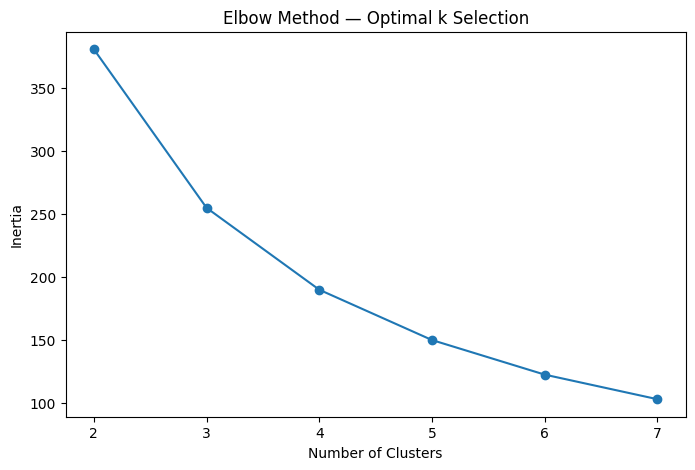


Cluster Summary:
   cluster  avg_density  avg_population  ward_count
0        0         0.49        66254.51         160
1        1         2.34        65403.62          78

Auto detected tier_map: {np.float64(0.0): 'Tier 1 - Urgent', np.float64(1.0): 'Tier 2 - Moderate'}

Final Tier Distribution:
tier
Tier 1 - Urgent      160
Tier 2 - Moderate     78
Tier 3 - Covered      12
Name: count, dtype: int64

--- Model Evaluation Metrics ---
Silhouette Score:      0.440  (higher is better, max 1.0)
Davies-Bouldin Score:  0.930  (lower is better, min 0.0)
Inertia:               380.67

⚠️ Silhouette Score 0.25-0.5 — clusters are reasonable, some overlap exists
✅ Davies-Bouldin < 1.0 — good cluster separation


In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ---- OUTLIER REMOVAL BEFORE CLUSTERING ----
# Identify wards with abnormally high charger density using IQR method
Q1 = merged_df_accurate['charger_density'].quantile(0.25)
Q3 = merged_df_accurate['charger_density'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

print(f"IQR upper boundary: {upper:.3f}")
print(f"Wards identified as outliers (Tier 3): {(merged_df_accurate['charger_density'] > upper).sum()}")

# Separate outliers and clean data
outliers = merged_df_accurate[merged_df_accurate['charger_density'] > upper].copy()
df_cluster = merged_df_accurate[merged_df_accurate['charger_density'] <= upper].copy()

print(f"\nOutlier wards (auto assigned to Tier 3 - Covered):")
print(outliers[['ward', 'total_population', 'total_chargers', 'charger_density']])

# ---- ELBOW METHOD on clean data ----
X = df_cluster[['total_population', 'total_chargers', 'charger_density']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia_values = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(range(2, 8), inertia_values, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k Selection')
plt.show()

# ---- KMEANS WITH k=2 on clean data ----
# After outlier removal, 2 clusters separate Tier 1 and Tier 2 cleanly
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# Auto detect tier labels based on average density
cluster_summary = df_cluster.groupby('cluster').agg(
    avg_density=('charger_density', 'mean'),
    avg_population=('total_population', 'mean'),
    ward_count=('ward', 'count')
).reset_index()

print("\nCluster Summary:")
print(cluster_summary.round(2))

# Sort by density — lowest = Tier 1 Urgent, highest = Tier 2 Moderate
cluster_summary = cluster_summary.sort_values('avg_density').reset_index(drop=True)
tier_labels = ['Tier 1 - Urgent', 'Tier 2 - Moderate']
tier_map = {row['cluster']: tier_labels[i] for i, row in cluster_summary.iterrows()}

print("\nAuto detected tier_map:", tier_map)
df_cluster['tier'] = df_cluster['cluster'].map(tier_map)

# Assign outliers to Tier 3
outliers['tier'] = 'Tier 3 - Covered'
outliers['cluster'] = 2

# Combine back into merged_df_accurate
merged_df_accurate = pd.concat([df_cluster, outliers]).sort_values('wardno').reset_index(drop=True)

print("\nFinal Tier Distribution:")
print(merged_df_accurate['tier'].value_counts())

# ---- MODEL EVALUATION ----
silhouette = silhouette_score(X_scaled, df_cluster['cluster'])
davies_bouldin = davies_bouldin_score(X_scaled, df_cluster['cluster'])
inertia = kmeans.inertia_

print(f"\n--- Model Evaluation Metrics ---")
print(f"Silhouette Score:      {silhouette:.3f}  (higher is better, max 1.0)")
print(f"Davies-Bouldin Score:  {davies_bouldin:.3f}  (lower is better, min 0.0)")
print(f"Inertia:               {inertia:.2f}")

if silhouette > 0.5:
    print("\n✅ Silhouette Score > 0.5 — clusters are well separated")
elif silhouette > 0.25:
    print("\n⚠️ Silhouette Score 0.25-0.5 — clusters are reasonable, some overlap exists")
else:
    print("\n❌ Silhouette Score < 0.25 — clusters are weak")

if davies_bouldin < 1.0:
    print("✅ Davies-Bouldin < 1.0 — good cluster separation")
else:
    print("⚠️ Davies-Bouldin > 1.0 — clusters have some overlap")


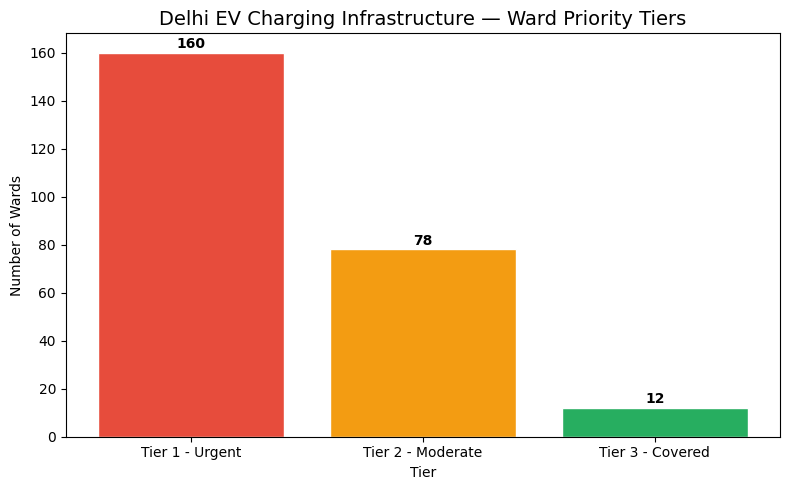

In [22]:
# Import necessary libraries for plotting.
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the counts of wards for each tier.
tier_counts = merged_df_accurate['tier'].value_counts()
# Define a custom color palette for the tiers.
colors = ['#e74c3c', '#f39c12', '#27ae60']

# Create a bar chart to visualize the distribution of wards across the different tiers.
plt.figure(figsize=(8,5))
bars = plt.bar(tier_counts.index, tier_counts.values, color=colors, edgecolor='white')
plt.title('Delhi EV Charging Infrastructure — Ward Priority Tiers', fontsize=14)
plt.ylabel('Number of Wards')
plt.xlabel('Tier')

# Add numerical labels on top of each bar.
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2,
             str(int(yval)), ha='center', fontweight='bold')

plt.tight_layout() # Adjust layout to prevent labels from overlapping.
plt.savefig('tier_distribution.png', dpi=150) # Save the plot as a PNG image.
plt.show() # Display the plot.

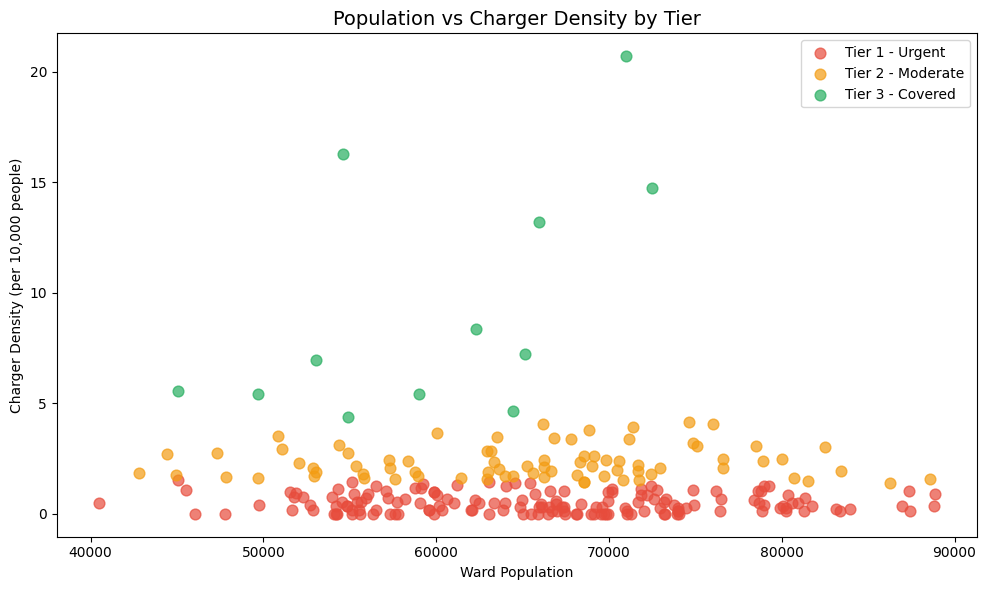

In [23]:
# Define a dictionary to map tiers to specific colors for consistent visualization.
colors_map = {'Tier 1 - Urgent': '#e74c3c',
              'Tier 2 - Moderate': '#f39c12',
              'Tier 3 - Covered': '#27ae60'}

# Create a scatter plot to visualize the relationship between ward population and charger density, colored by tier.
plt.figure(figsize=(10,6))
# Iterate through each tier group in the merged DataFrame.
for tier, group in merged_df_accurate.groupby('tier'):
    # Plot scatter points for each ward, using population on the x-axis and charger density on the y-axis.
    plt.scatter(group['total_population'], group['charger_density'],
                label=tier, color=colors_map[tier], alpha=0.7, s=60) # Set label, color, transparency, and size of points.

plt.xlabel('Ward Population') # Label for the x-axis.
plt.ylabel('Charger Density (per 10,000 people)') # Label for the y-axis.
plt.title('Population vs Charger Density by Tier', fontsize=14) # Title of the plot.
plt.legend() # Display the legend to differentiate tiers.
plt.tight_layout() # Adjust layout to prevent labels from overlapping.
plt.savefig('scatter_plot.png', dpi=150) # Save the plot as a PNG image.
plt.show() # Display the plot.

In [24]:
# Check if there are any null values in the 'boundary_wkt' column of the 'merged_df'.
print(merged_df_accurate['boundary_wkt'].isnull().sum())

# Import the `wkt` module from `shapely` for handling Well-Known Text (WKT) geometries.
from shapely import wkt
# Load the WKT string of the first ward's boundary into a shapely geometry object for testing.
test = wkt.loads(merged_df_accurate['boundary_wkt'].iloc[0])
# Print the geometry type of the loaded object.
print(test.geom_type)
# Print whether the geometry object is valid.
print(test.is_valid)

0
Polygon
True


In [25]:
# Filter the 'merged_df' to select only wards categorized as 'Tier 1 - Urgent'.
# Then, sort these wards by 'total_population' in descending order to find the most populated urgent wards.
# Select and display relevant columns: 'ward', 'total_population', 'total_chargers', and 'charger_density'.
# Finally, take the top 10 rows.
top_urgent = merged_df_accurate[merged_df_accurate['tier'] == 'Tier 1 - Urgent']\
    .sort_values('total_population', ascending=False)\
    [['ward', 'total_population', 'total_chargers', 'charger_density']]\
    .head(10)
# Print the resulting DataFrame of top urgent wards.
print(top_urgent)

                    ward  total_population  total_chargers  charger_density
190  MAYUR VIHAR PHASE-I             88878             8.0         0.900110
191           TRILOKPURI             88792             3.0         0.337868
65             WAZIR PUR             87397             1.0         0.114420
194           KALYANPURI             87375             9.0         1.030043
113               NAWADA             86959             3.0         0.344990
217         SUNDAR NAGRI             83935             2.0         0.238280
245       SRI RAM COLONY             83347             1.0         0.119980
123     NANGLI SAKRAWATI             83159             2.0         0.240503
38            MUBARIKPUR             81734             3.0         0.367044
49          MANGOLPURI-B             81344             6.0         0.737608


In [26]:
import folium
# Create a base Folium map centered on Delhi
delhi_map = folium.Map(location=[28.6139, 77.2090], zoom_start=11)

# Layer 1: Draw ward polygons, colored by their assigned tier
for _, row in merged_df_accurate.iterrows():
    geom = wkt.loads(row['boundary_wkt'])
    coords = []
    if geom.geom_type == 'Polygon':
        coords = [[y, x] for x, y in geom.exterior.coords]
        if coords:
            folium.Polygon(
                locations=coords,
                color='white',
                weight=0.5,
                fill=True,
                fill_color=colors_map[row['tier']],
                fill_opacity=0.7,
                tooltip=f"Ward: {row['ward']}<br>Population: {row['total_population']}<br>Chargers: {int(row['total_chargers'])}<br>{row['tier']}"
            ).add_to(delhi_map)
    elif geom.geom_type == 'MultiPolygon':
        for poly in geom.geoms:
            if poly.exterior:
                coords = [[y, x] for x, y in poly.exterior.coords]
                if coords:
                    folium.Polygon(
                        locations=coords,
                        color='white',
                        weight=0.5,
                        fill=True,
                        fill_color=colors_map[row['tier']],
                        fill_opacity=0.7,
                        tooltip=f"Ward: {row['ward']}<br>Population: {row['total_population']}<br>Chargers: {int(row['total_chargers'])}<br>{row['tier']}"
                    ).add_to(delhi_map)

# # Layer 2: Add ONLY chargers that are within Delhi
# # Using latitude_left and longitude_left based on the DataFrame structure
for _, row in matched_proj.iterrows():
    folium.CircleMarker(
        location=[row['latitude_left'], row['longitude_left']],
        radius=3,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.8,
        tooltip=f"Charger: {row['name']}"
    ).add_to(delhi_map)

# Legend HTML
legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 10px; border-radius: 8px;
     border: 1px solid grey; font-size: 13px;">
     <b>EV Charger Priority</b><br>
     <i style="background:#e74c3c; width:12px; height:12px;
        display:inline-block; margin-right:6px;"></i>Tier 1 - Urgent<br>
     <i style="background:#f39c12; width:12px; height:12px;
        display:inline-block; margin-right:6px;"></i>Tier 2 - Moderate<br>
     <i style="background:#27ae60; width:12px; height:12px;
        display:inline-block; margin-right:6px;"></i>Tier 3 - Covered<br>
     <i style="background:blue; width:12px; height:12px;
        display:inline-block; margin-right:6px; border-radius:50%;"></i>Existing Charger
</div>
'''
delhi_map.get_root().html.add_child(folium.Element(legend_html))

# Save the generated map to an HTML file
delhi_map.save('delhi_ev_map_final.html')
print("done")

done
